In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [29]:
df.duplicated().sum()

np.int64(723)

In [5]:
df.corr()['target']

,target
age,-0.229324
sex,-0.279501
cp,0.434854
trestbps,-0.138772
chol,-0.099966
fbs,-0.041164
restecg,0.134468
thalach,0.422895
exang,-0.438029
oldpeak,-0.438441


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [24]:
x = df.drop('target',axis=1)
y = df.target

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0, stratify=y)



In [26]:
x_train.shape,x_test.shape

((820, 13), (205, 13))

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

In [30]:
model = keras.Sequential([

    layers.Dense(256, activation='relu', input_shape=(13,),
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    # Hidden layer 2: 8 neurons
    layers.Dense(32, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(4, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(2, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    # Output layer: 1 neuron (binary classification)
    layers.Dense(1, activation='sigmoid')
])

# Display model architecture
print("Model Architecture:")
model.summary()

# Compile the model
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\nModel compiled successfully!")
print(f"Total parameters: {model.count_params():,}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,321 (192.66 KB)

 Trainable params: 48,425 (189.16 KB)

 Non-trainable params: 896 (3.50 KB)


Model compiled successfully!
Total parameters: 49,321


In [33]:
print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Set up callbacks
callbacks = [
    # Early stopping
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=0.00001,
        verbose=1
    ),
    # Save best model
    keras.callbacks.ModelCheckpoint(
        'best_diabetes_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,              # Maximum epochs
    batch_size=16,           # Batch size
    validation_split=0.2,    # 20% of training data for validation
    callbacks=callbacks,
    verbose=1
)

print("\nModel training completed!")

MODEL TRAINING
Epoch 1/100
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5228 - auc: 0.5501 - loss: 1.0483
Epoch 1: val_accuracy improved from None to 0.71951, saving model to best_diabetes_model.keras

Epoch 1: finished saving model to best_diabetes_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5305 - auc: 0.5507 - loss: 1.0376 - val_accuracy: 0.7195 - val_auc: 0.5707 - val_loss: 1.0234 - learning_rate: 0.0010
Epoch 2/100
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4990 - auc: 0.5500 - loss: 1.0105
Epoch 2: val_accuracy did not improve from 0.71951
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5488 - auc: 0.6082 - loss: 0.9970 - val_accuracy: 0.7134 - val_auc: 0.6885 - val_loss: 0.9904 - learning_rate: 0.0010
Epoch 3/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6502 - auc: 0.6876 - loss: 0.9551
Epoch 3: val_accuracy improved from 0.71951 to 0.84756, saving model to best_diabetes_model.keras

Epoch 3: finished saving model to best_

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# 1. Evaluate on test set
test_loss, test_accuracy, test_auc = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  AUC: {test_auc:.4f}")

# 2. Make predictions
predictions = model.predict(x_test_scaled)
predicted_classes = (predictions > 0.5).astype(int)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, predicted_classes)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives:  {cm[1,1]}")

# 4. Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, predicted_classes,
                           target_names=['No Diabetes', 'Diabetes']))

# 5. ROC AUC
roc_auc = roc_auc_score(y_test, predictions)
print(f"ROC AUC Score: {roc_auc:.4f}")

MODEL EVALUATION

Test Results:
  Loss: 0.2855
  Accuracy: 0.9512
  AUC: 0.9658
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Confusion Matrix:
  True Negatives:  100
  False Positives: 0
  False Negatives: 10
  True Positives:  95

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.91      1.00      0.95       100
    Diabetes       1.00      0.90      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.96      0.95      0.95       205

ROC AUC Score: 0.9648


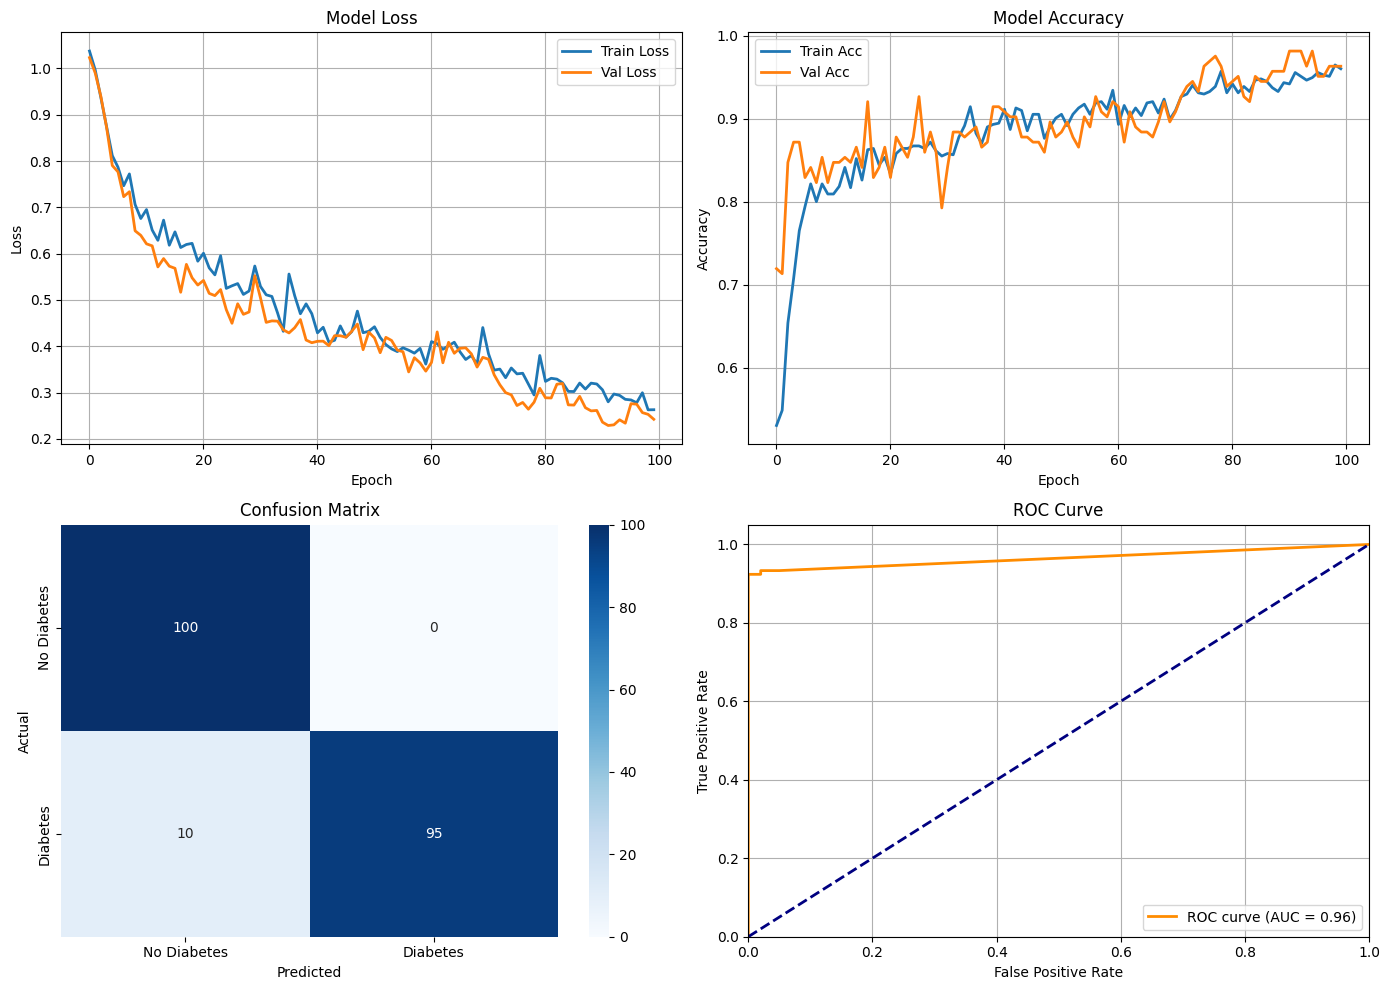

In [38]:
# Create evaluation dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training History
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Training Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions)
axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [40]:
print("=" * 60)
print("SAVE AND LOAD MODEL")
print("=" * 60)

# Save the model
model.save('diabetes_model_final.keras')
print("Model saved as 'diabetes_model_final.keras'")

# Save the scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

# Test loading the model
loaded_model = keras.models.load_model('diabetes_model_final.keras')
print("\nModel loaded successfully!")

# Verify loaded model works
test_prediction = loaded_model.predict(x_test_scaled[:5])
print(f"Sample predictions from loaded model: {test_prediction.flatten()}")

SAVE AND LOAD MODEL
Model saved as 'diabetes_model_final.keras'
Scaler saved as 'scaler.pkl'

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
Sample predictions from loaded model: [0.16871624 0.16871624 0.16871624 1.         0.9998463 ]
